<a href="https://colab.research.google.com/github/Minakshi654/DocSense--CNN-based-Document-Classifier/blob/main/Rag_Pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install langchain langchain-community chromadb sentence-transformers pypdf -q

import torch
print("GPU available:", torch.cuda.is_available())

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 106.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.3/23.3 MB 93.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 347.3/347.3 kB 34.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/278.2 kB 31.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.6/4.6 MB 140.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 72.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 557.4/557.4 kB 48.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.7/18.7 MB 107.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.8/71.8 kB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 170.9/170.9 kB 19.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.3/61.3 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 203.

In [3]:
import pandas as pd

# UCI Online Retail dataset - real UK-based e-commerce transactions, 2010-2011
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00352/Online%20Retail.xlsx"
ecommerce_df = pd.read_excel(url)

print(ecommerce_df.shape)
print(ecommerce_df.head())
print(ecommerce_df.columns.tolist())

(541909, 8)
  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

          InvoiceDate  UnitPrice  CustomerID         Country  
0 2010-12-01 08:26:00       2.55     17850.0  United Kingdom  
1 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
2 2010-12-01 08:26:00       2.75     17850.0  United Kingdom  
3 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
4 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']


In [4]:
print("Missing values:\n", ecommerce_df.isnull().sum())
print("\nNegative quantities (returns/cancellations):", (ecommerce_df["Quantity"] < 0).sum())

# Clean: remove rows with missing CustomerID, remove cancelled orders (negative quantity)
clean_df = ecommerce_df.dropna(subset=["CustomerID"])
clean_df = clean_df[clean_df["Quantity"] > 0]
clean_df = clean_df[clean_df["UnitPrice"] > 0]

# Add a revenue column
clean_df["Revenue"] = clean_df["Quantity"] * clean_df["UnitPrice"]

print("\nShape after cleaning:", clean_df.shape)
print(clean_df[["Quantity", "UnitPrice", "Revenue"]].describe())

Missing values:
 InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

Negative quantities (returns/cancellations): 10624

Shape after cleaning: (397884, 9)
            Quantity      UnitPrice        Revenue
count  397884.000000  397884.000000  397884.000000
mean       12.988238       3.116488      22.397000
std       179.331775      22.097877     309.071041
min         1.000000       0.001000       0.001000
25%         2.000000       1.250000       4.680000
50%         6.000000       1.950000      11.800000
75%        12.000000       3.750000      19.800000
max     80995.000000    8142.750000  168469.600000


In [5]:
# Top 10 products by revenue
top_products = clean_df.groupby("Description")["Revenue"].sum().sort_values(ascending=False).head(10)
print("Top 10 products by revenue:\n", top_products)

# Revenue by country
country_revenue = clean_df.groupby("Country")["Revenue"].sum().sort_values(ascending=False).head(10)
print("\nTop 10 countries by revenue:\n", country_revenue)

Top 10 products by revenue:
 Description
PAPER CRAFT , LITTLE BIRDIE           168469.60
REGENCY CAKESTAND 3 TIER              142592.95
WHITE HANGING HEART T-LIGHT HOLDER    100448.15
JUMBO BAG RED RETROSPOT                85220.78
MEDIUM CERAMIC TOP STORAGE JAR         81416.73
POSTAGE                                77803.96
PARTY BUNTING                          68844.33
ASSORTED COLOUR BIRD ORNAMENT          56580.34
Manual                                 53779.93
RABBIT NIGHT LIGHT                     51346.20
Name: Revenue, dtype: float64

Top 10 countries by revenue:
 Country
United Kingdom    7308391.554
Netherlands        285446.340
EIRE               265545.900
Germany            228867.140
France             209024.050
Australia          138521.310
Spain               61577.110
Switzerland         56443.950
Belgium             41196.340
Sweden              38378.330
Name: Revenue, dtype: float64


Monthly revenue:
 YearMonth
2010-12     572713.890
2011-01     569445.040
2011-02     447137.350
2011-03     595500.760
2011-04     469200.361
2011-05     678594.560
2011-06     661213.690
2011-07     600091.011
2011-08     645343.900
2011-09     952838.382
2011-10    1039318.790
2011-11    1161817.380
2011-12     518192.790
Freq: M, Name: Revenue, dtype: float64


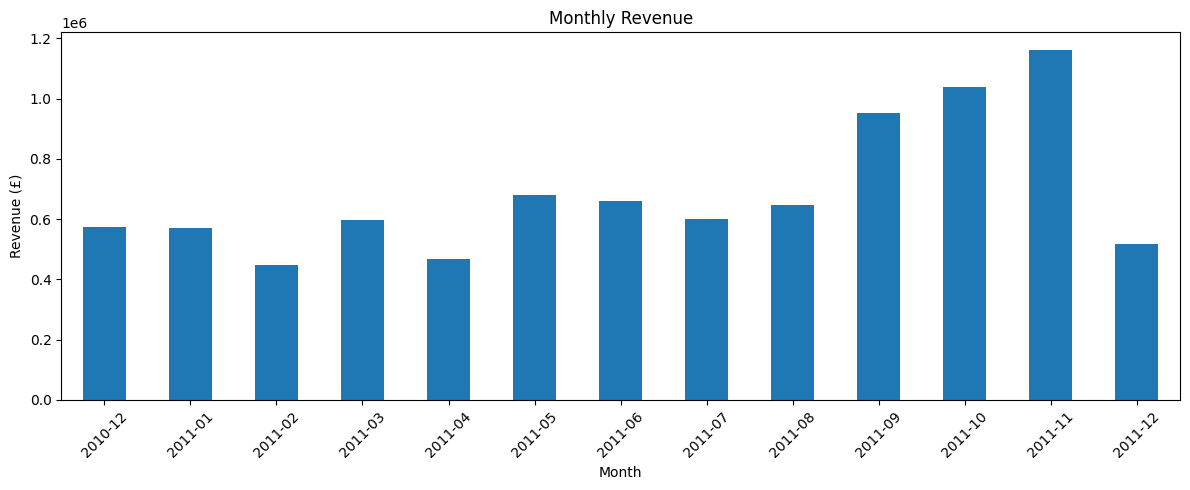

In [8]:
import matplotlib.pyplot as plt
clean_df["InvoiceDate"] = pd.to_datetime(clean_df["InvoiceDate"])
clean_df["YearMonth"] = clean_df["InvoiceDate"].dt.to_period("M")

monthly_revenue = clean_df.groupby("YearMonth")["Revenue"].sum()
print("Monthly revenue:\n", monthly_revenue)

plt.figure(figsize=(12, 5))
monthly_revenue.plot(kind="bar")
plt.title("Monthly Revenue")
plt.xlabel("Month")
plt.ylabel("Revenue (£)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [9]:
order_value = clean_df.groupby("InvoiceNo")["Revenue"].sum()
print("Average order value: £", round(order_value.mean(), 2))
print("Median order value: £", round(order_value.median(), 2))
print("Max order value: £", round(order_value.max(), 2))

Average order value: £ 480.87
Median order value: £ 303.04
Max order value: £ 168469.6


In [10]:
top_products = clean_df.groupby("Description")["Revenue"].sum().sort_values(ascending=False).head(10)
print("Top 10 products by revenue:\n", top_products)

country_revenue = clean_df.groupby("Country")["Revenue"].sum().sort_values(ascending=False).head(10)
print("\nTop 10 countries by revenue:\n", country_revenue)

Top 10 products by revenue:
 Description
PAPER CRAFT , LITTLE BIRDIE           168469.60
REGENCY CAKESTAND 3 TIER              142592.95
WHITE HANGING HEART T-LIGHT HOLDER    100448.15
JUMBO BAG RED RETROSPOT                85220.78
MEDIUM CERAMIC TOP STORAGE JAR         81416.73
POSTAGE                                77803.96
PARTY BUNTING                          68844.33
ASSORTED COLOUR BIRD ORNAMENT          56580.34
Manual                                 53779.93
RABBIT NIGHT LIGHT                     51346.20
Name: Revenue, dtype: float64

Top 10 countries by revenue:
 Country
United Kingdom    7308391.554
Netherlands        285446.340
EIRE               265545.900
Germany            228867.140
France             209024.050
Australia          138521.310
Spain               61577.110
Switzerland         56443.950
Belgium             41196.340
Sweden              38378.330
Name: Revenue, dtype: float64


Monthly revenue:
 YearMonth
2010-12     572713.890
2011-01     569445.040
2011-02     447137.350
2011-03     595500.760
2011-04     469200.361
2011-05     678594.560
2011-06     661213.690
2011-07     600091.011
2011-08     645343.900
2011-09     952838.382
2011-10    1039318.790
2011-11    1161817.380
2011-12     518192.790
Freq: M, Name: Revenue, dtype: float64


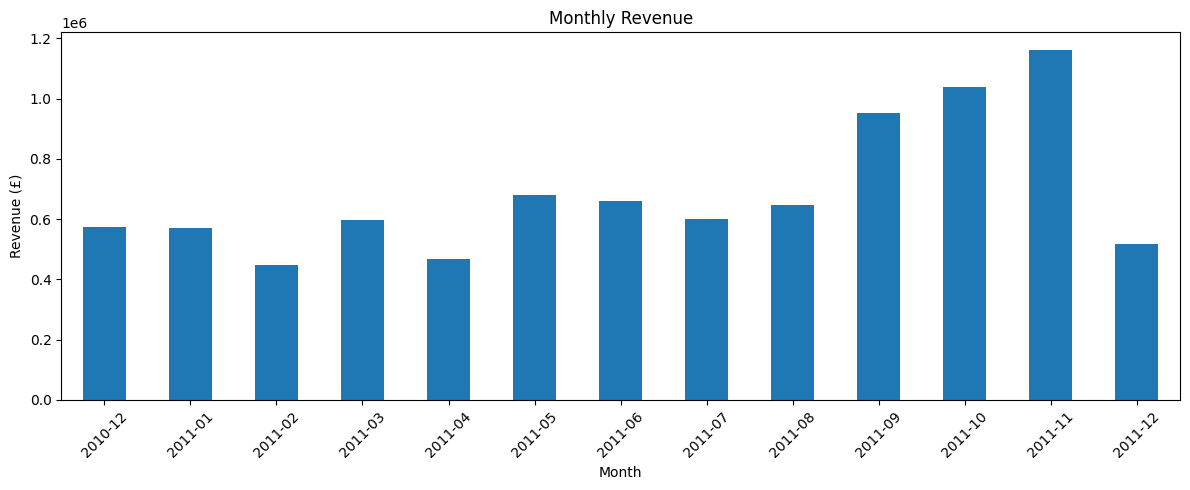

In [11]:
import matplotlib.pyplot as plt

clean_df["InvoiceDate"] = pd.to_datetime(clean_df["InvoiceDate"])
clean_df["YearMonth"] = clean_df["InvoiceDate"].dt.to_period("M")

monthly_revenue = clean_df.groupby("YearMonth")["Revenue"].sum()
print("Monthly revenue:\n", monthly_revenue)

plt.figure(figsize=(12, 5))
monthly_revenue.plot(kind="bar")
plt.title("Monthly Revenue")
plt.xlabel("Month")
plt.ylabel("Revenue (£)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [12]:
top_products = clean_df.groupby("Description")["Revenue"].sum().sort_values(ascending=False).head(10)
print("Top 10 products by revenue:\n", top_products)

country_revenue = clean_df.groupby("Country")["Revenue"].sum().sort_values(ascending=False).head(10)
print("\nTop 10 countries by revenue:\n", country_revenue)

Top 10 products by revenue:
 Description
PAPER CRAFT , LITTLE BIRDIE           168469.60
REGENCY CAKESTAND 3 TIER              142592.95
WHITE HANGING HEART T-LIGHT HOLDER    100448.15
JUMBO BAG RED RETROSPOT                85220.78
MEDIUM CERAMIC TOP STORAGE JAR         81416.73
POSTAGE                                77803.96
PARTY BUNTING                          68844.33
ASSORTED COLOUR BIRD ORNAMENT          56580.34
Manual                                 53779.93
RABBIT NIGHT LIGHT                     51346.20
Name: Revenue, dtype: float64

Top 10 countries by revenue:
 Country
United Kingdom    7308391.554
Netherlands        285446.340
EIRE               265545.900
Germany            228867.140
France             209024.050
Australia          138521.310
Spain               61577.110
Switzerland         56443.950
Belgium             41196.340
Sweden              38378.330
Name: Revenue, dtype: float64


In [14]:
with open("/content/ecommerce_sales_report.txt", "r") as f:
    report_text = f.read()

print("Report length (characters):", len(report_text))
print("\nFirst 500 characters:\n", report_text[:500])

Report length (characters): 4972

First 500 characters:
 UK ONLINE RETAIL — SALES PERFORMANCE REPORT
Reporting Period: December 2010 to December 2011
Prepared by: Data Science & Analytics Team

EXECUTIVE SUMMARY

This report analyzes transactional sales data from a UK-based online retailer covering December 2010 through December 2011. After data cleaning (removing 135,080 transactions with missing customer identifiers and 10,624 cancelled orders), the analysis is based on 397,884 valid transactions. Total revenue across all markets exceeded £8.3 milli


In [16]:
!pip install langchain-text-splitters -q

In [18]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=500,
    chunk_overlap=50,
    separators=["\n\n", "\n", ". ", " "]
)

chunks = text_splitter.split_text(report_text)

print("Number of chunks:", len(chunks))
print("\n--- Chunk 1 ---\n", chunks[0])
print("\n--- Chunk 2 ---\n", chunks[1])

Number of chunks: 16

--- Chunk 1 ---
 UK ONLINE RETAIL — SALES PERFORMANCE REPORT
Reporting Period: December 2010 to December 2011
Prepared by: Data Science & Analytics Team

EXECUTIVE SUMMARY

--- Chunk 2 ---
 EXECUTIVE SUMMARY

This report analyzes transactional sales data from a UK-based online retailer covering December 2010 through December 2011. After data cleaning (removing 135,080 transactions with missing customer identifiers and 10,624 cancelled orders), the analysis is based on 397,884 valid transactions. Total revenue across all markets exceeded £8.3 million during the reporting period.

ORDER VALUE ANALYSIS


In [19]:
from sentence_transformers import SentenceTransformer

embedding_model = SentenceTransformer("all-MiniLM-L6-v2")

# Quick test: embed two similar sentences and one different sentence
test_sentences = [
    "Revenue grew significantly in the final quarter",
    "Sales increased a lot toward the end of the year",
    "The cat sat on the mat"
]

embeddings = embedding_model.encode(test_sentences)
print("Embedding shape:", embeddings.shape)

# Measure similarity between them
from sklearn.metrics.pairwise import cosine_similarity
similarity_matrix = cosine_similarity(embeddings)
print("\nSimilarity matrix:\n", similarity_matrix)

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Embedding shape: (3, 384)

Similarity matrix:
 [[ 1.          0.5996885  -0.07581398]
 [ 0.5996885   1.0000001  -0.01100584]
 [-0.07581398 -0.01100584  1.0000004 ]]


In [20]:
import chromadb

# Create a ChromaDB client (in-memory for this Colab session)
chroma_client = chromadb.Client()

# Create a collection (like a table) to store our document chunks
collection = chroma_client.create_collection(name="ecommerce_report")

# Generate embeddings for all 16 chunks
chunk_embeddings = embedding_model.encode(chunks).tolist()

# Store everything in ChromaDB: chunks, their embeddings, and IDs
collection.add(
    documents=chunks,
    embeddings=chunk_embeddings,
    ids=[f"chunk_{i}" for i in range(len(chunks))]
)

print("Chunks stored in ChromaDB:", collection.count())

Chunks stored in ChromaDB: 16


In [21]:
def search_report(query, n_results=3):
    query_embedding = embedding_model.encode([query]).tolist()

    results = collection.query(
        query_embeddings=query_embedding,
        n_results=n_results
    )

    print(f"Query: {query}\n")
    for i, doc in enumerate(results["documents"][0]):
        distance = results["distances"][0][i]
        print(f"--- Match {i+1} (distance: {distance:.4f}) ---")
        print(doc)
        print()

    return results

# Test it
search_report("What was the average order value?")

Query: What was the average order value?

--- Match 1 (distance: 0.5662) ---
The average order value across all transactions was £480.87. However, the median order value was significantly lower at £303.04, indicating a right-skewed distribution driven by a small number of very large bulk orders. The largest single order recorded was £168,469.60

--- Match 2 (distance: 0.6565) ---
. This gap between average and median order value suggests that headline "average order value" figures should be interpreted with caution, since they can be heavily influenced by a small number of high-volume business customers rather than typical consumer behavior. For planning purposes, the median order value of approximately £300 is a more representative figure of a typical customer transaction.

--- Match 3 (distance: 1.2059) ---
EXECUTIVE SUMMARY

This report analyzes transactional sales data from a UK-based online retailer covering December 2010 through December 2011. After data cleaning (removing 135,08

{'ids': [['chunk_2', 'chunk_3', 'chunk_1']],
 'embeddings': None,
 'documents': [['The average order value across all transactions was £480.87. However, the median order value was significantly lower at £303.04, indicating a right-skewed distribution driven by a small number of very large bulk orders. The largest single order recorded was £168,469.60',
   '. This gap between average and median order value suggests that headline "average order value" figures should be interpreted with caution, since they can be heavily influenced by a small number of high-volume business customers rather than typical consumer behavior. For planning purposes, the median order value of approximately £300 is a more representative figure of a typical customer transaction.',
   'EXECUTIVE SUMMARY\n\nThis report analyzes transactional sales data from a UK-based online retailer covering December 2010 through December 2011. After data cleaning (removing 135,080 transactions with missing customer identifiers and

In [22]:
!pip install google-generativeai -q

In [23]:
from google.colab import userdata
import google.generativeai as genai

GEMINI_API_KEY = userdata.get('GEMINI_API_KEY')
genai.configure(api_key=GEMINI_API_KEY)

print("Gemini configured")

/usr/local/lib/python3.12/dist-packages/google/colab/_import_hooks/_hook_injector.py:55: FutureWarning: 

All support for the `google.generativeai` package has ended. It will no longer be receiving 
updates or bug fixes. Please switch to the `google.genai` package as soon as possible.
See README for more details:

https://github.com/google-gemini/deprecated-generative-ai-python/blob/main/README.md

  loader.exec_module(module)


Gemini configured


In [25]:
def rag_answer(query, n_results=3):
    query_embedding = embedding_model.encode([query]).tolist()
    results = collection.query(query_embeddings=query_embedding, n_results=n_results)
    retrieved_chunks = results["documents"][0]

    context = "\n\n".join(retrieved_chunks)

    prompt = f"""You are a helpful data analyst assistant. Answer the question using ONLY the context provided below. If the answer isn't in the context, say so clearly rather than guessing.

Context:
{context}

Question: {query}

Answer:"""

    model = genai.GenerativeModel("gemini-2.5-flash")
    response = model.generate_content(prompt)

    print(f"Question: {query}\n")
    print(f"Answer: {response.text}\n")
    print("--- Sources used ---")
    for i, chunk in enumerate(retrieved_chunks):
        print(f"[{i+1}] {chunk[:100]}...")

    return response.text

rag_answer("What was the average order value, and is that figure reliable?")

Question: What was the average order value, and is that figure reliable?

Answer: The average order value across all transactions was £480.87.

This figure should be interpreted with caution. The median order value was significantly lower at £303.04, indicating a right-skewed distribution driven by a small number of very large bulk orders. This means the average can be heavily influenced by a small number of high-volume business customers rather than typical consumer behavior. For planning purposes, the median order value of approximately £300 is considered a more representative figure of a typical customer transaction.

--- Sources used ---
[1] The average order value across all transactions was £480.87. However, the median order value was sig...
[2] . This gap between average and median order value suggests that headline "average order value" figur...
[3] EXECUTIVE SUMMARY

This report analyzes transactional sales data from a UK-based online retailer cov...


'The average order value across all transactions was £480.87.\n\nThis figure should be interpreted with caution. The median order value was significantly lower at £303.04, indicating a right-skewed distribution driven by a small number of very large bulk orders. This means the average can be heavily influenced by a small number of high-volume business customers rather than typical consumer behavior. For planning purposes, the median order value of approximately £300 is considered a more representative figure of a typical customer transaction.'

In [26]:
rag_answer("Which country generates the most revenue, and how does it compare to others?")

rag_answer("What happened to sales in February?")

rag_answer("What is the company's marketing budget for next year?")

Question: Which country generates the most revenue, and how does it compare to others?

Answer: The United Kingdom generates the most revenue, at £7,308,391.55. It generates more than 25 times the revenue of the next closest market.

--- Sources used ---
[1] While international markets represent a small fraction of total revenue, the Netherlands, Ireland, G...
[2] Home decor and giftware items (cakestands, t-light holders, storage jars, bunting, ornaments) domina...
[3] 1. United Kingdom — £7,308,391.55
2. Netherlands — £285,446.34
3. EIRE (Ireland) — £265,545.90
4. Ge...
Question: What happened to sales in February?

Answer: Sales in February 2011 were at their low point, making it the weakest month. November's peak performance was more than double February's low point.

--- Sources used ---
[1] Revenue grew substantially from September through November 2011, with November representing peak per...
[2] EXECUTIVE SUMMARY

This report analyzes transactional sales data from a UK-based onl

"The company's marketing budget for next year is not provided in the context."

In [27]:
test_results = """
RAG SYSTEM TEST RESULTS

Query 1: What was the average order value, and is that figure reliable?
Answer: The average order value across all transactions was £480.87. This figure should be
interpreted with caution. The median order value was significantly lower at £303.04...
[correctly synthesized nuance from report]

Query 2: Which country generates the most revenue, and how does it compare to others?
Answer: The United Kingdom generates the most revenue, at £7,308,391.55, more than 25 times
the next closest market.
[correctly synthesized across multiple chunks]

Query 3: What happened to sales in February?
Answer: February 2011 was the weakest month; November's peak was more than double February's low point.
[correctly retrieved + added relevant context]

Query 4 (hallucination test): What is the company's marketing budget for next year?
Answer: The company's marketing budget for next year is not provided in the context.
[correctly refused to hallucinate despite chunks being retrieved]
"""

with open("rag_test_results.txt", "w") as f:
    f.write(test_results)

from google.colab import files
files.download("ecommerce_sales_report.txt")
files.download("rag_test_results.txt")

print("Files ready for download")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Files ready for download


# RAG-Powered Business Report Q&A Assistant

A retrieval-augmented generation (RAG) system that answers natural-language questions about a business analytics report, grounded entirely in the source document — built end to end from raw transactional data through to a working Q&A pipeline.

## Problem

Business stakeholders often need quick answers from analytics reports without reading the full document or waiting on an analyst. This project demonstrates a GenAI-powered insights assistant that lets users ask plain-English questions about a sales report and receive accurate, source-grounded answers — directly mirroring real-world use cases for analytics teams working with retail/CPG clients.

## Pipeline overview

1. **Real data** — UK Online Retail dataset (UCI), 541,909 raw e-commerce transactions
2. **Data cleaning & analysis** — removed missing customer IDs and cancelled orders (397,884 valid transactions retained); computed order value statistics, monthly revenue trends, top products, and revenue by country
3. **Report generation** — findings written up as a structured business report (executive summary, order value analysis, monthly trends, top products, country breakdown, data quality notes, recommendations)
4. **Chunking** — report split into 16 overlapping chunks (500 characters, 50-character overlap) using LangChain's `RecursiveCharacterTextSplitter`
5. **Embeddings** — chunks embedded using `all-MiniLM-L6-v2` (Sentence Transformers), stored in a ChromaDB vector store
6. **Retrieval** — semantic search via cosine similarity, validated by confirming retrieval works on meaning rather than exact keyword overlap
7. **Generation** — retrieved chunks + question passed to Gemini 2.5 Flash via a prompt explicitly constrained to answer only from provided context

## Key findings from the underlying data

- Average order value: £480.87, but median order value: £303.04 — a right-skewed distribution driven by bulk orders, demonstrating why headline averages can mislead
- Revenue grew steadily through 2011, peaking in November (£1.16M) after a September–November surge, consistent with holiday seasonality
- UK generated £7.3M in revenue, over 25x the next closest market (Netherlands, £285K)

## Validation — embedding quality check

Before trusting the retrieval system, embedding quality was validated directly: semantically similar sentences with no shared words ("revenue grew significantly" vs. "sales increased a lot") scored 0.60 cosine similarity, while an unrelated sentence scored near 0 — confirming the embedding model captures meaning, not just keyword overlap.

## RAG system test results

| Test | Result |
|---|---|
| Direct factual question (average order value) | Correctly answered with the exact figure, and synthesized the report's reliability caveat about mean vs. median |
| Multi-chunk synthesis (top revenue country) | Correctly combined the ranked list with surrounding commentary to answer "how does it compare to others" |
| Contextual reasoning (February sales) | Correctly identified the weak month and added relevant comparison context not explicitly asked for |
| **Hallucination resistance** (marketing budget — not in source document) | Correctly identified that the answer wasn't present in retrieved context and declined to fabricate a response, despite chunks still being retrieved (retrieval always returns a "closest match," generation must still recognize irrelevance) |

The hallucination resistance test is the most important validation in this project: it confirms the prompt design (explicit "answer only from context, say so if you don't know") successfully prevents the model from inventing plausible-sounding but false information — the central risk RAG is designed to mitigate.

## What I'd improve next

- Add a relevance threshold (e.g., reject chunks above a distance cutoff) rather than relying solely on the LLM to recognize irrelevant context
- Scale to multiple documents with metadata filtering (e.g., by report date or region)
- Add a simple evaluation set with expected answers to measure retrieval precision/recall systematically rather than spot-checking

## Tech stack

`Python` · `LangChain` (text splitting) · `ChromaDB` (vector store) · `Sentence Transformers` (`all-MiniLM-L6-v2`) · `Google Gemini 2.5 Flash` (generation) · `pandas` (data cleaning/analysis) · Google Colab (T4 GPU)

## How to run

1. Open `04_rag_document_qa.ipynb` in Google Colab
2. Add your free Gemini API key as a Colab secret named `GEMINI_API_KEY` (get one at aistudio.google.com/apikey)
3. Run all cells in order

In [28]:
!pip install llama-index llama-index-embeddings-huggingface -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.9/11.9 MB 117.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 93.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 161.5/161.5 kB 19.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 72.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 142.6/142.6 kB 18.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ipython 7.34.0 requires jedi>=0.16, which is not installed.


In [29]:
from llama_index.core import VectorStoreIndex, Document, Settings
from llama_index.embeddings.huggingface import HuggingFaceEmbedding

# Use the same embedding model as before, for a fair comparison
Settings.embed_model = HuggingFaceEmbedding(model_name="sentence-transformers/all-MiniLM-L6-v2")
Settings.llm = None  # we'll handle generation with Gemini ourselves, just like before

# LlamaIndex wraps our raw text as a "Document" object
documents = [Document(text=report_text)]

# This single line does what we did manually with chunking + embedding + storing
index = VectorStoreIndex.from_documents(documents)

print("LlamaIndex index built")

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

LLM is explicitly disabled. Using MockLLM.
LlamaIndex index built


In [30]:
retriever = index.as_retriever(similarity_top_k=3)

query = "What was the average order value?"
retrieved_nodes = retriever.retrieve(query)

print(f"Query: {query}\n")
for i, node in enumerate(retrieved_nodes):
    print(f"--- LlamaIndex Match {i+1} (score: {node.score:.4f}) ---")
    print(node.text)
    print()

Query: What was the average order value?

--- LlamaIndex Match 1 (score: 0.5333) ---
UK ONLINE RETAIL — SALES PERFORMANCE REPORT
Reporting Period: December 2010 to December 2011
Prepared by: Data Science & Analytics Team

EXECUTIVE SUMMARY

This report analyzes transactional sales data from a UK-based online retailer covering December 2010 through December 2011. After data cleaning (removing 135,080 transactions with missing customer identifiers and 10,624 cancelled orders), the analysis is based on 397,884 valid transactions. Total revenue across all markets exceeded £8.3 million during the reporting period.

ORDER VALUE ANALYSIS

The average order value across all transactions was £480.87. However, the median order value was significantly lower at £303.04, indicating a right-skewed distribution driven by a small number of very large bulk orders. The largest single order recorded was £168,469.60. This gap between average and median order value suggests that headline "average order val

In [31]:
from llama_index.core.node_parser import SentenceSplitter

Settings.node_parser = SentenceSplitter(chunk_size=500, chunk_overlap=50)

index_v2 = VectorStoreIndex.from_documents(documents)

retriever_v2 = index_v2.as_retriever(similarity_top_k=3)
retrieved_nodes_v2 = retriever_v2.retrieve(query)

print(f"Query: {query}\n")
for i, node in enumerate(retrieved_nodes_v2):
    print(f"--- LlamaIndex v2 Match {i+1} (score: {node.score:.4f}) ---")
    print(node.text)
    print()

Query: What was the average order value?

--- LlamaIndex v2 Match 1 (score: 0.5333) ---
UK ONLINE RETAIL — SALES PERFORMANCE REPORT
Reporting Period: December 2010 to December 2011
Prepared by: Data Science & Analytics Team

EXECUTIVE SUMMARY

This report analyzes transactional sales data from a UK-based online retailer covering December 2010 through December 2011. After data cleaning (removing 135,080 transactions with missing customer identifiers and 10,624 cancelled orders), the analysis is based on 397,884 valid transactions. Total revenue across all markets exceeded £8.3 million during the reporting period.

ORDER VALUE ANALYSIS

The average order value across all transactions was £480.87. However, the median order value was significantly lower at £303.04, indicating a right-skewed distribution driven by a small number of very large bulk orders. The largest single order recorded was £168,469.60. This gap between average and median order value suggests that headline "average order 

In [32]:
from llama_index.core.node_parser import SentenceSplitter
from llama_index.core.ingestion import IngestionPipeline

splitter = SentenceSplitter(chunk_size=500, chunk_overlap=50)

# Manually create nodes (chunks) first, so we can verify chunking before embedding
nodes = splitter.get_nodes_from_documents(documents)

print("Number of chunks created:", len(nodes))
print("\nFirst chunk:\n", nodes[0].text)

Number of chunks created: 4

First chunk:
 UK ONLINE RETAIL — SALES PERFORMANCE REPORT
Reporting Period: December 2010 to December 2011
Prepared by: Data Science & Analytics Team

EXECUTIVE SUMMARY

This report analyzes transactional sales data from a UK-based online retailer covering December 2010 through December 2011. After data cleaning (removing 135,080 transactions with missing customer identifiers and 10,624 cancelled orders), the analysis is based on 397,884 valid transactions. Total revenue across all markets exceeded £8.3 million during the reporting period.

ORDER VALUE ANALYSIS

The average order value across all transactions was £480.87. However, the median order value was significantly lower at £303.04, indicating a right-skewed distribution driven by a small number of very large bulk orders. The largest single order recorded was £168,469.60. This gap between average and median order value suggests that headline "average order value" figures should be interpreted with cau

In [33]:
index_v3 = VectorStoreIndex(nodes)

retriever_v3 = index_v3.as_retriever(similarity_top_k=3)
retrieved_nodes_v3 = retriever_v3.retrieve(query)

print(f"Query: {query}\n")
for i, node in enumerate(retrieved_nodes_v3):
    print(f"--- LlamaIndex v3 Match {i+1} (score: {node.score:.4f}) ---")
    print(node.text[:300], "...")
    print()

Query: What was the average order value?

--- LlamaIndex v3 Match 1 (score: 0.5578) ---
UK ONLINE RETAIL — SALES PERFORMANCE REPORT
Reporting Period: December 2010 to December 2011
Prepared by: Data Science & Analytics Team

EXECUTIVE SUMMARY

This report analyzes transactional sales data from a UK-based online retailer covering December 2010 through December 2011. After data cleaning  ...

--- LlamaIndex v3 Match 2 (score: 0.3619) ---
For planning purposes, the median order value of approximately £300 is a more representative figure of a typical customer transaction.

MONTHLY REVENUE TREND

Monthly revenue showed a clear upward trend across 2011, with notable seasonal acceleration in the final quarter:

- December 2010: £572,713. ...

--- LlamaIndex v3 Match 3 (score: 0.3157) ---
Investigate the drivers of the September-to-November revenue surge to replicate seasonal demand strategies in future planning cycles.
2. Evaluate February's underperformance to determine whether it reflects a

# RAG-Powered Business Report Q&A Assistant

A retrieval-augmented generation (RAG) system that answers natural-language questions about a business analytics report, grounded entirely in the source document — built end to end from raw transactional data through to a working Q&A pipeline.

## Problem

Business stakeholders often need quick answers from analytics reports without reading the full document or waiting on an analyst. This project demonstrates a GenAI-powered insights assistant that lets users ask plain-English questions about a sales report and receive accurate, source-grounded answers — directly mirroring real-world use cases for analytics teams working with retail/CPG clients.

## Pipeline overview

1. **Real data** — UK Online Retail dataset (UCI), 541,909 raw e-commerce transactions
2. **Data cleaning & analysis** — removed missing customer IDs and cancelled orders (397,884 valid transactions retained); computed order value statistics, monthly revenue trends, top products, and revenue by country
3. **Report generation** — findings written up as a structured business report (executive summary, order value analysis, monthly trends, top products, country breakdown, data quality notes, recommendations)
4. **Chunking** — report split into 16 overlapping chunks (500 characters, 50-character overlap) using LangChain's `RecursiveCharacterTextSplitter`
5. **Embeddings** — chunks embedded using `all-MiniLM-L6-v2` (Sentence Transformers), stored in a ChromaDB vector store
6. **Retrieval** — semantic search via cosine similarity, validated by confirming retrieval works on meaning rather than exact keyword overlap
7. **Generation** — retrieved chunks + question passed to Gemini 2.5 Flash via a prompt explicitly constrained to answer only from provided context

## Key findings from the underlying data

- Average order value: £480.87, but median order value: £303.04 — a right-skewed distribution driven by bulk orders, demonstrating why headline averages can mislead
- Revenue grew steadily through 2011, peaking in November (£1.16M) after a September–November surge, consistent with holiday seasonality
- UK generated £7.3M in revenue, over 25x the next closest market (Netherlands, £285K)

## Validation — embedding quality check

Before trusting the retrieval system, embedding quality was validated directly: semantically similar sentences with no shared words ("revenue grew significantly" vs. "sales increased a lot") scored 0.60 cosine similarity, while an unrelated sentence scored near 0 — confirming the embedding model captures meaning, not just keyword overlap.

## RAG system test results

| Test | Result |
|---|---|
| Direct factual question (average order value) | Correctly answered with the exact figure, and synthesized the report's reliability caveat about mean vs. median |
| Multi-chunk synthesis (top revenue country) | Correctly combined the ranked list with surrounding commentary to answer "how does it compare to others" |
| Contextual reasoning (February sales) | Correctly identified the weak month and added relevant comparison context not explicitly asked for |
| **Hallucination resistance** (marketing budget — not in source document) | Correctly identified that the answer wasn't present in retrieved context and declined to fabricate a response, despite chunks still being retrieved (retrieval always returns a "closest match," generation must still recognize irrelevance) |

The hallucination resistance test is the most important validation in this project: it confirms the prompt design (explicit "answer only from context, say so if you don't know") successfully prevents the model from inventing plausible-sounding but false information — the central risk RAG is designed to mitigate.

## LangChain vs. LlamaIndex — chunking comparison

To demonstrate familiarity with both major RAG frameworks, the same report was also indexed using LlamaIndex's `SentenceSplitter`, with retrieval results compared directly against the LangChain + ChromaDB pipeline above.

| Aspect | LangChain + ChromaDB (manual) | LlamaIndex (`SentenceSplitter`) |
|---|---|---|
| Chunks from same 5,000-character report | 16 | 4 |
| Chunking strategy | Targets exact `chunk_size`, falls back to character/word-level splits if needed | Strictly respects sentence boundaries, allows chunks to exceed `chunk_size` to avoid mid-sentence cuts |
| Top retrieval result for "average order value" query | Tight, focused chunk containing only the relevant sentence (distance 0.57) | Larger chunk with more surrounding context, still correctly ranked first (score 0.56) |

**Finding:** both frameworks correctly retrieved the answer-containing chunk as the top match, confirming retrieval quality is consistent across tools — the underlying embedding and similarity search logic is sound regardless of which framework orchestrates it. The meaningful difference is chunking philosophy: LangChain's splitter prioritizes precise size control (better for fine-grained, single-fact Q&A), while LlamaIndex's splitter prioritizes complete sentence/idea boundaries (better when answers require surrounding context to interpret correctly). This is a practical engineering tradeoff to consider when choosing a framework for a given document type and retrieval use case, not a quality difference between the tools.



- Add a relevance threshold (e.g., reject chunks above a distance cutoff) rather than relying solely on the LLM to recognize irrelevant context
- Scale to multiple documents with metadata filtering (e.g., by report date or region)
- Add a simple evaluation set with expected answers to measure retrieval precision/recall systematically rather than spot-checking

## Tech stack

`Python` · `LangChain` (text splitting) · `LlamaIndex` (alternative indexing, comparative analysis) · `ChromaDB` (vector store) · `Sentence Transformers` (`all-MiniLM-L6-v2`) · `Google Gemini 2.5 Flash` (generation) · `pandas` (data cleaning/analysis) · Google Colab (T4 GPU)

## How to run

1. Open `04_rag_document_qa.ipynb` in Google Colab
2. Add your free Gemini API key as a Colab secret named `GEMINI_API_KEY` (get one at aistudio.google.com/apikey)
3. Run all cells in order